Fitted parameters:
  Vmax = 0.1950 mmol/(L·hr)
  Km   = 0.1804 mmol/L
  kcat = Vmax / CE0 = 19.4998 hr⁻¹


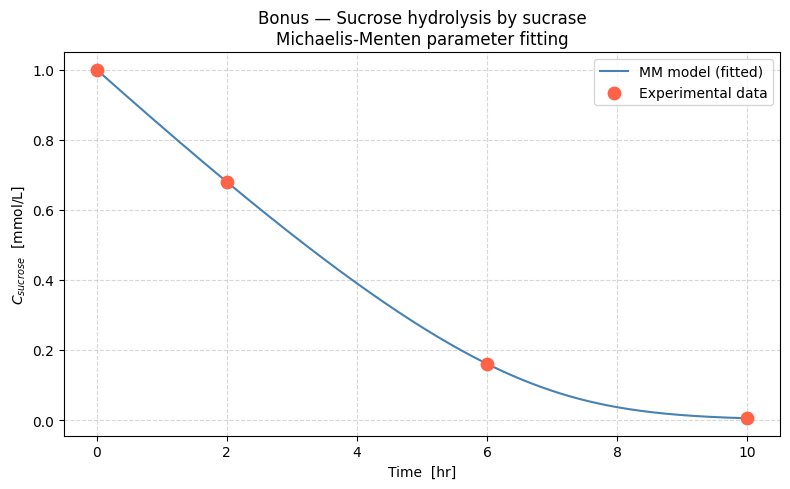

In [3]:
"""
Bonus Question - Finding Michaelis-Menten kinetic parameters
for sucrose hydrolysis by sucrase.

Strategy:
- The MM equation gives: -dS/dt = Vmax * S / (Km + S)
- We integrate this ODE numerically and fit Km and Vmax
  to match the experimental sucrose concentration data.
- Vmax = kcat * CE0, so once Vmax is found: kcat = Vmax / CE0
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit

# =============================================================
# EXPERIMENTAL DATA
# =============================================================
t_exp = np.array([0, 2, 6, 10])            # hr
S_exp = np.array([1, 0.68, 0.16, 0.006])   # mmol/L
CE0   = 0.01                                # mmol/L

# =============================================================
# FUNCTION : integrate MM ODE and return S at experimental times
# params = [Vmax, Km]
# =============================================================
def MM_model(t_eval, Vmax, Km):
    def dS_dt(t, S):
        return [-Vmax * S[0] / (Km + S[0])]

    sol = solve_ivp(dS_dt,
                    t_span=(t_eval[0], t_eval[-1]),
                    y0=[S_exp[0]],
                    t_eval=t_eval,
                    method='RK45',
                    rtol=1e-8, atol=1e-10)
    return sol.y[0]

# =============================================================
# FIT Vmax and Km using curve_fit
# =============================================================
popt, pcov = curve_fit(MM_model,
                       t_exp,
                       S_exp,
                       p0=[0.1, 0.5],
                       bounds=(0, np.inf))

Vmax_fit, Km_fit = popt
kcat_fit = Vmax_fit / CE0

print(f"Fitted parameters:")
print(f"  Vmax = {Vmax_fit:.4f} mmol/(L·hr)")
print(f"  Km   = {Km_fit:.4f} mmol/L")
print(f"  kcat = Vmax / CE0 = {kcat_fit:.4f} hr⁻¹")

# =============================================================
# PLOT : experimental data vs fitted model
# =============================================================
t_fine = np.linspace(0, 10, 500)
S_fit  = MM_model(t_fine, Vmax_fit, Km_fit)

plt.figure(figsize=(8, 5))
plt.plot(t_fine, S_fit, color='steelblue', label='MM model (fitted)')
plt.scatter(t_exp, S_exp, color='tomato', zorder=5, s=80, label='Experimental data')
plt.xlabel("Time  [hr]")
plt.ylabel("$C_{sucrose}$  [mmol/L]")
plt.title("Bonus — Sucrose hydrolysis by sucrase\nMichaelis-Menten parameter fitting")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()